# EEG_00_feature_significance

Questo notebook sostituisce la vecchia idea dei **cluster semantici** con una cosa più utile in questa fase:

## Obiettivo
Valutare **quanto le feature EEG calcolate siano statisticamente associate** a:
- la **parola** (`label_id`)
- il **soggetto** (`subject_id`)
- opzionalmente la **sessione**

## Idea
Partiamo dai tensori **aggregated** per soggetto:
- `X`: `(n_trials, 59, 40)`

Per ogni trial costruiamo una tabella trial-level con:
- media sui canali per ciascuna feature
- std sui canali per ciascuna feature

Poi facciamo test statistici feature-wise:
- **Kruskal-Wallis** su `label_id`
- **Kruskal-Wallis** su `subject_id`
- correzione multipla **FDR (Benjamini-Hochberg)**
- effect size robusta (**epsilon squared**)

In questo modo otteniamo:
- feature più associate alla parola
- feature più associate al soggetto
- confronto diretto: **word effect vs subject effect**

Data: 2026-03-07


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt


## Paths and setup


In [2]:
project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)

agg_dir = project_root / "data" / "processed" / "subject_tensors" / "subject_tensors_aggregated_epoch"
assert agg_dir.exists(), f"Missing {agg_dir}"

files = sorted(agg_dir.glob("subject_*.pt"))
print("num subject files:", len(files))
assert len(files) > 0, "No aggregated subject tensors found"


num subject files: 74


## Load feature names


In [3]:
first = torch.load(files[0], map_location="cpu")
feature_cols = first["feature_cols"]
print("num base features:", len(feature_cols))
print(feature_cols[:10])


num base features: 40
['func_max_corr', 'func_max_plv', 'func_mean_corr', 'func_mean_plv', 'func_num_strong_conn', 'func_std_corr', 'spec_alpha', 'spec_alpha_beta_ratio', 'spec_alpha_rel', 'spec_beta']


/tmp/ipykernel_8215/769025979.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  first = torch.load(files[0], map_location="cpu")


## Build trial-level dataframe

Per ogni trial estraiamo:

- `mean__<feature>` = media sui 59 canali
- `std__<feature>` = deviazione standard sui 59 canali

Così possiamo testare sia:
- il livello medio della feature
- la variabilità spaziale della feature


In [4]:
rows = []

for p in files:
    obj = torch.load(p, map_location="cpu")
    X = obj["X"].numpy()   # (n_trials, 59, 40)
    y = obj["y"].numpy()
    subj = obj["subject_id"].numpy()
    sess = obj["session_id"].numpy()
    epoch = obj["epoch_idx"].numpy()

    X_mean = X.mean(axis=1)   # (n_trials, 40)
    X_std = X.std(axis=1)     # (n_trials, 40)

    for i in range(X.shape[0]):
        row = {
            "label_id": int(y[i]),
            "subject_id": int(subj[i]),
            "session_id": int(sess[i]),
            "epoch_idx": int(epoch[i]),
        }

        for j, feat in enumerate(feature_cols):
            row[f"mean__{feat}"] = float(X_mean[i, j])
            row[f"std__{feat}"] = float(X_std[i, j])

        rows.append(row)

df = pd.DataFrame(rows)
print("df shape:", df.shape)
df.head(3)


/tmp/ipykernel_8215/1534614611.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(p, map_location="cpu")


df shape: (38926, 84)


,label_id,subject_id,session_id,epoch_idx,mean__func_max_corr,std__func_max_corr,mean__func_max_plv,std__func_max_plv,mean__func_mean_corr,std__func_mean_corr,...,mean__temp_rms,std__temp_rms,mean__temp_skewness,std__temp_skewness,mean__temp_std,std__temp_std,mean__temp_var,std__temp_var,mean__temp_zcr,std__temp_zcr
0,62,0,1,0,0.695255,0.166144,0.629643,0.146267,0.317266,0.097356,...,6.845750,2.955184,0.027984,0.415654,6.80034,2.964087,55.030434,53.536633,0.182866,0.056778
1,15,0,1,1,0.646923,0.198432,0.598266,0.188738,0.216843,0.071435,...,5.991394,2.815066,-0.059431,0.333508,5.93407,2.816761,43.147324,54.695396,0.185867,0.057197
2,40,0,1,2,0.587939,0.143470,0.538878,0.118776,0.172075,0.036804,...,4.614281,1.420164,-0.020226,0.230531,4.56507,1.403934,22.810894,12.568068,0.216852,0.044512


## Optional: decode label names


In [5]:
label2idx_path = project_root / "data" / "interim" / "label2idx.json"
if label2idx_path.exists():
    with open(label2idx_path, "r", encoding="utf-8") as f:
        label2idx = json.load(f)
    idx2label = {int(v): k for k, v in label2idx.items()}
    df["word"] = df["label_id"].map(idx2label)
    print("Added column: word")
else:
    print("label2idx.json not found, skipping word names")


Added column: word


## Feature columns used for statistical testing


In [6]:
test_feature_cols = [c for c in df.columns if c.startswith("mean__") or c.startswith("std__")]
print("num test columns:", len(test_feature_cols))
print(test_feature_cols[:8])


num test columns: 80
['mean__func_max_corr', 'std__func_max_corr', 'mean__func_max_plv', 'std__func_max_plv', 'mean__func_mean_corr', 'std__func_mean_corr', 'mean__func_mean_plv', 'std__func_mean_plv']


## Helper: Kruskal-Wallis + epsilon squared

Usiamo Kruskal-Wallis perché:
- non richiede normalità forte
- è robusto
- ha senso come primo test esplorativo

### Epsilon squared
Useremo:

`epsilon_sq = (H - k + 1) / (n - k)`

dove:
- `H` = statistica Kruskal
- `k` = numero gruppi
- `n` = numero osservazioni


In [7]:
def kruskal_feature_test(df, feature_col, group_col, min_group_size=2):
    tmp = df[[feature_col, group_col]].dropna()

    groups = []
    for g, sub in tmp.groupby(group_col):
        vals = sub[feature_col].values
        if len(vals) >= min_group_size:
            groups.append(vals)

    k = len(groups)
    n = sum(len(g) for g in groups)

    if k < 2:
        return {
            "feature": feature_col,
            "group_col": group_col,
            "n_groups": k,
            "n_total": n,
            "H": np.nan,
            "p_value": np.nan,
            "epsilon_sq": np.nan,
        }

    H, p = kruskal(*groups)

    if n > k:
        epsilon_sq = (H - k + 1) / (n - k)
    else:
        epsilon_sq = np.nan

    return {
        "feature": feature_col,
        "group_col": group_col,
        "n_groups": k,
        "n_total": n,
        "H": float(H),
        "p_value": float(p),
        "epsilon_sq": float(epsilon_sq),
    }


## Run tests: effect of **word** (`label_id`)


In [8]:
word_results = []
for feat in test_feature_cols:
    word_results.append(kruskal_feature_test(df, feat, "label_id"))

word_results = pd.DataFrame(word_results)

mask = word_results["p_value"].notna()
rej, p_fdr, _, _ = multipletests(word_results.loc[mask, "p_value"], method="fdr_bh")
word_results.loc[mask, "p_fdr"] = p_fdr
word_results.loc[mask, "significant_fdr"] = rej

word_results = word_results.sort_values(["p_fdr", "epsilon_sq"], ascending=[True, False]).reset_index(drop=True)
word_results.head(15)


,feature,group_col,n_groups,n_total,H,p_value,epsilon_sq,p_fdr,significant_fdr
0,mean__temp_mean,label_id,110,38926,101.843415,0.673758,-0.000184,1.0,False
1,mean__temp_skewness,label_id,110,38926,83.355908,0.967796,-0.000661,1.0,False
2,std__temp_kurtosis,label_id,110,38926,81.665964,0.976560,-0.000704,1.0,False
3,std__temp_skewness,label_id,110,38926,69.975759,0.998652,-0.001005,1.0,False
4,std__spec_dominant_power,label_id,110,38926,68.938084,0.999018,-0.001032,1.0,False
5,std__spec_theta,label_id,110,38926,67.127101,0.999452,-0.001079,1.0,False
6,std__spec_theta_rel,label_id,110,38926,65.342116,0.999703,-0.001125,1.0,False
7,std__temp_max,label_id,110,38926,61.650203,0.999926,-0.001220,1.0,False
8,std__spec_delta_rel,label_id,110,38926,58.062936,0.999984,-0.001312,1.0,False
9,std__spec_delta,label_id,110,38926,56.081101,0.999994,-0.001363,1.0,False


## Run tests: effect of **subject** (`subject_id`)


In [9]:
subject_results = []
for feat in test_feature_cols:
    subject_results.append(kruskal_feature_test(df, feat, "subject_id"))

subject_results = pd.DataFrame(subject_results)

mask = subject_results["p_value"].notna()
rej, p_fdr, _, _ = multipletests(subject_results.loc[mask, "p_value"], method="fdr_bh")
subject_results.loc[mask, "p_fdr"] = p_fdr
subject_results.loc[mask, "significant_fdr"] = rej

subject_results = subject_results.sort_values(["p_fdr", "epsilon_sq"], ascending=[True, False]).reset_index(drop=True)
subject_results.head(15)


,feature,group_col,n_groups,n_total,H,p_value,epsilon_sq,p_fdr,significant_fdr
0,mean__func_max_corr,subject_id,74,38926,35978.018622,0.0,0.924149,0.0,True
1,mean__func_max_plv,subject_id,74,38926,35285.468635,0.0,0.906323,0.0,True
2,mean__func_std_corr,subject_id,74,38926,35025.642385,0.0,0.899636,0.0,True
3,std__func_max_corr,subject_id,74,38926,33858.979034,0.0,0.869607,0.0,True
4,mean__func_mean_corr,subject_id,74,38926,33560.456299,0.0,0.861924,0.0,True
5,mean__func_num_strong_conn,subject_id,74,38926,33017.550180,0.0,0.847950,0.0,True
6,mean__func_mean_plv,subject_id,74,38926,31894.969608,0.0,0.819056,0.0,True
7,mean__spec_beta,subject_id,74,38926,31375.902136,0.0,0.805696,0.0,True
8,std__func_max_plv,subject_id,74,38926,31108.492428,0.0,0.798813,0.0,True
9,mean__spec_edge_freq,subject_id,74,38926,30106.893718,0.0,0.773033,0.0,True


## Optional: effect of **session** (`session_id`)


In [10]:
session_results = []
for feat in test_feature_cols:
    session_results.append(kruskal_feature_test(df, feat, "session_id"))

session_results = pd.DataFrame(session_results)

mask = session_results["p_value"].notna()
rej, p_fdr, _, _ = multipletests(session_results.loc[mask, "p_value"], method="fdr_bh")
session_results.loc[mask, "p_fdr"] = p_fdr
session_results.loc[mask, "significant_fdr"] = rej

session_results = session_results.sort_values(["p_fdr", "epsilon_sq"], ascending=[True, False]).reset_index(drop=True)
session_results.head(15)


,feature,group_col,n_groups,n_total,H,p_value,epsilon_sq,p_fdr,significant_fdr
0,std__temp_zcr,session_id,6,38926,504.616405,8.049709e-107,0.012837,6.439767e-105,True
1,std__spec_mean_freq,session_id,6,38926,497.181822,3.240027e-105,0.012646,1.296011e-103,True
2,std__temp_hjorth_mobility,session_id,6,38926,436.164259,4.736004e-92,0.011078,1.262934e-90,True
3,std__spec_median_freq,session_id,6,38926,435.043628,8.262015e-92,0.011049,1.652403e-90,True
4,std__temp_hjorth_complexity,session_id,6,38926,390.367117,3.533617e-82,0.009902,5.653787e-81,True
5,std__temp_ptp,session_id,6,38926,372.539964,2.449319e-78,0.009443,2.799221e-77,True
6,std__temp_range,session_id,6,38926,372.539964,2.449319e-78,0.009443,2.799221e-77,True
7,std__temp_max,session_id,6,38926,370.226198,7.716788e-78,0.009384,7.716788e-77,True
8,mean__spec_dominant_freq,session_id,6,38926,368.473881,1.840235e-77,0.009339,1.635765e-76,True
9,std__spec_alpha_rel,session_id,6,38926,367.877898,2.473094e-77,0.009324,1.978475e-76,True


## Quick summary


In [11]:
print("Significant features for WORD effect (FDR<0.05):", int(word_results["significant_fdr"].fillna(False).sum()))
print("Significant features for SUBJECT effect (FDR<0.05):", int(subject_results["significant_fdr"].fillna(False).sum()))
print("Significant features for SESSION effect (FDR<0.05):", int(session_results["significant_fdr"].fillna(False).sum()))


Significant features for WORD effect (FDR<0.05): 0
Significant features for SUBJECT effect (FDR<0.05): 80
Significant features for SESSION effect (FDR<0.05): 80


/tmp/ipykernel_8215/2799772710.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print("Significant features for WORD effect (FDR<0.05):", int(word_results["significant_fdr"].fillna(False).sum()))
/tmp/ipykernel_8215/2799772710.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print("Significant features for SUBJECT effect (FDR<0.05):", int(subject_results["significant_fdr"].fillna(False).sum()))
/tmp/ipykernel_8215/2799772710.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future ver

## Compare word effect vs subject effect

Questa è la tabella più importante:
per ogni feature confrontiamo direttamente l'effect size rispetto a:
- parola
- soggetto


In [12]:
cmp = (
    word_results[["feature", "H", "p_fdr", "epsilon_sq"]]
    .rename(columns={"H": "H_word", "p_fdr": "p_fdr_word", "epsilon_sq": "eps_word"})
    .merge(
        subject_results[["feature", "H", "p_fdr", "epsilon_sq"]]
        .rename(columns={"H": "H_subject", "p_fdr": "p_fdr_subject", "epsilon_sq": "eps_subject"}),
        on="feature",
        how="inner"
    )
)

cmp["subject_minus_word"] = cmp["eps_subject"] - cmp["eps_word"]
cmp = cmp.sort_values("subject_minus_word", ascending=False).reset_index(drop=True)
cmp.head(20)


,feature,H_word,p_fdr_word,eps_word,H_subject,p_fdr_subject,eps_subject,subject_minus_word
0,mean__func_max_corr,6.620960,1.0,-0.002638,35978.018622,0.0,0.924149,0.926786
1,mean__func_max_plv,9.043031,1.0,-0.002575,35285.468635,0.0,0.906323,0.908898
2,mean__func_std_corr,10.606768,1.0,-0.002535,35025.642385,0.0,0.899636,0.902170
3,std__func_max_corr,9.879991,1.0,-0.002554,33858.979034,0.0,0.869607,0.872161
4,mean__func_mean_corr,11.930278,1.0,-0.002501,33560.456299,0.0,0.861924,0.864424
5,mean__func_num_strong_conn,13.654451,1.0,-0.002456,33017.550180,0.0,0.847950,0.850406
6,mean__func_mean_plv,16.922290,1.0,-0.002372,31894.969608,0.0,0.819056,0.821428
7,mean__spec_beta,19.845023,1.0,-0.002297,31375.902136,0.0,0.805696,0.807993
8,std__func_max_plv,14.715871,1.0,-0.002429,31108.492428,0.0,0.798813,0.801242
9,mean__spec_edge_freq,20.441911,1.0,-0.002281,30106.893718,0.0,0.773033,0.775315


## Plot: word effect vs subject effect


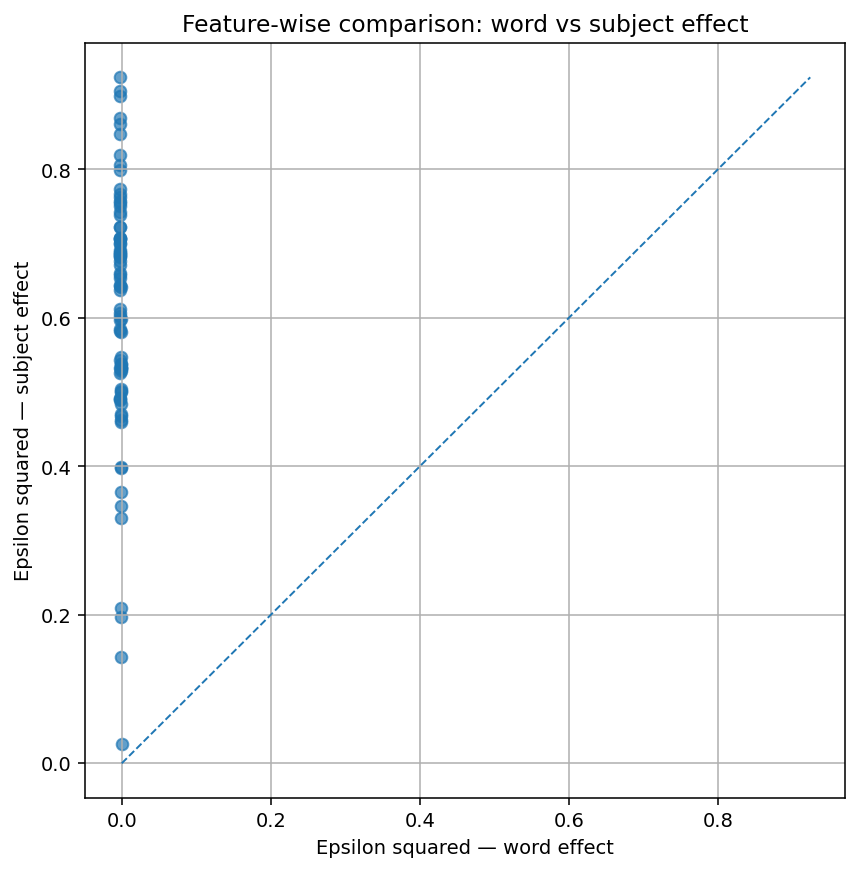

In [13]:
plt.figure(figsize=(7, 7), dpi=140)
plt.scatter(cmp["eps_word"], cmp["eps_subject"], alpha=0.7)
plt.xlabel("Epsilon squared — word effect")
plt.ylabel("Epsilon squared — subject effect")
plt.title("Feature-wise comparison: word vs subject effect")

mx = np.nanmax([
    np.nanmax(cmp["eps_word"].values),
    np.nanmax(cmp["eps_subject"].values)
])
plt.plot([0, mx], [0, mx], "--", linewidth=1)
plt.grid(True)
plt.show()


## Top features for word effect


In [14]:
word_top = word_results.sort_values(["epsilon_sq", "p_fdr"], ascending=[False, True]).head(20)
word_top


,feature,group_col,n_groups,n_total,H,p_value,epsilon_sq,p_fdr,significant_fdr
0,mean__temp_mean,label_id,110,38926,101.843415,0.673758,-0.000184,1.0,False
1,mean__temp_skewness,label_id,110,38926,83.355908,0.967796,-0.000661,1.0,False
2,std__temp_kurtosis,label_id,110,38926,81.665964,0.976560,-0.000704,1.0,False
3,std__temp_skewness,label_id,110,38926,69.975759,0.998652,-0.001005,1.0,False
4,std__spec_dominant_power,label_id,110,38926,68.938084,0.999018,-0.001032,1.0,False
5,std__spec_theta,label_id,110,38926,67.127101,0.999452,-0.001079,1.0,False
6,std__spec_theta_rel,label_id,110,38926,65.342116,0.999703,-0.001125,1.0,False
7,std__temp_max,label_id,110,38926,61.650203,0.999926,-0.001220,1.0,False
8,std__spec_delta_rel,label_id,110,38926,58.062936,0.999984,-0.001312,1.0,False
9,std__spec_delta,label_id,110,38926,56.081101,0.999994,-0.001363,1.0,False


## Top features for subject effect


In [15]:
subject_top = subject_results.sort_values(["epsilon_sq", "p_fdr"], ascending=[False, True]).head(20)
subject_top


,feature,group_col,n_groups,n_total,H,p_value,epsilon_sq,p_fdr,significant_fdr
0,mean__func_max_corr,subject_id,74,38926,35978.018622,0.0,0.924149,0.0,True
1,mean__func_max_plv,subject_id,74,38926,35285.468635,0.0,0.906323,0.0,True
2,mean__func_std_corr,subject_id,74,38926,35025.642385,0.0,0.899636,0.0,True
3,std__func_max_corr,subject_id,74,38926,33858.979034,0.0,0.869607,0.0,True
4,mean__func_mean_corr,subject_id,74,38926,33560.456299,0.0,0.861924,0.0,True
5,mean__func_num_strong_conn,subject_id,74,38926,33017.550180,0.0,0.847950,0.0,True
6,mean__func_mean_plv,subject_id,74,38926,31894.969608,0.0,0.819056,0.0,True
7,mean__spec_beta,subject_id,74,38926,31375.902136,0.0,0.805696,0.0,True
8,std__func_max_plv,subject_id,74,38926,31108.492428,0.0,0.798813,0.0,True
9,mean__spec_edge_freq,subject_id,74,38926,30106.893718,0.0,0.773033,0.0,True


## Bar plot: top 15 word-related features


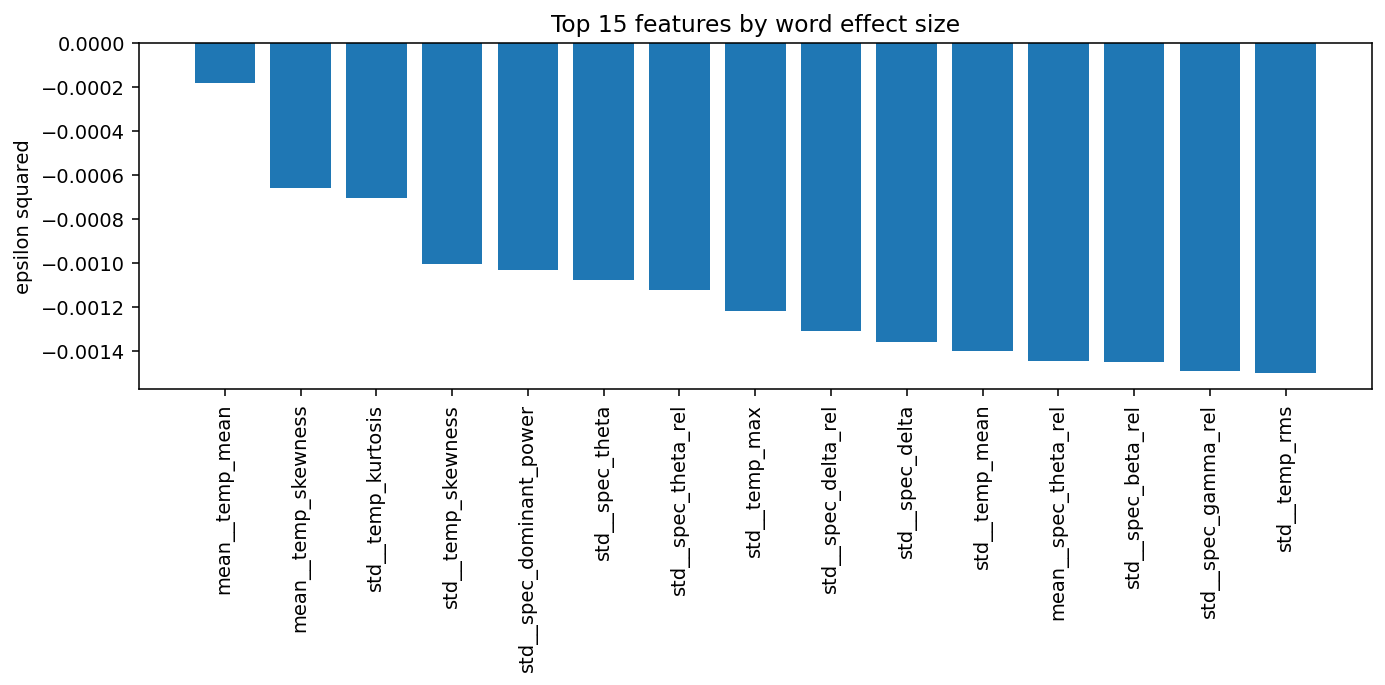

In [16]:
top15 = word_results.sort_values("epsilon_sq", ascending=False).head(15).copy()

plt.figure(figsize=(10, 5), dpi=140)
plt.bar(range(len(top15)), top15["epsilon_sq"].values)
plt.xticks(range(len(top15)), top15["feature"].values, rotation=90)
plt.ylabel("epsilon squared")
plt.title("Top 15 features by word effect size")
plt.tight_layout()
plt.show()


## Bar plot: top 15 subject-related features


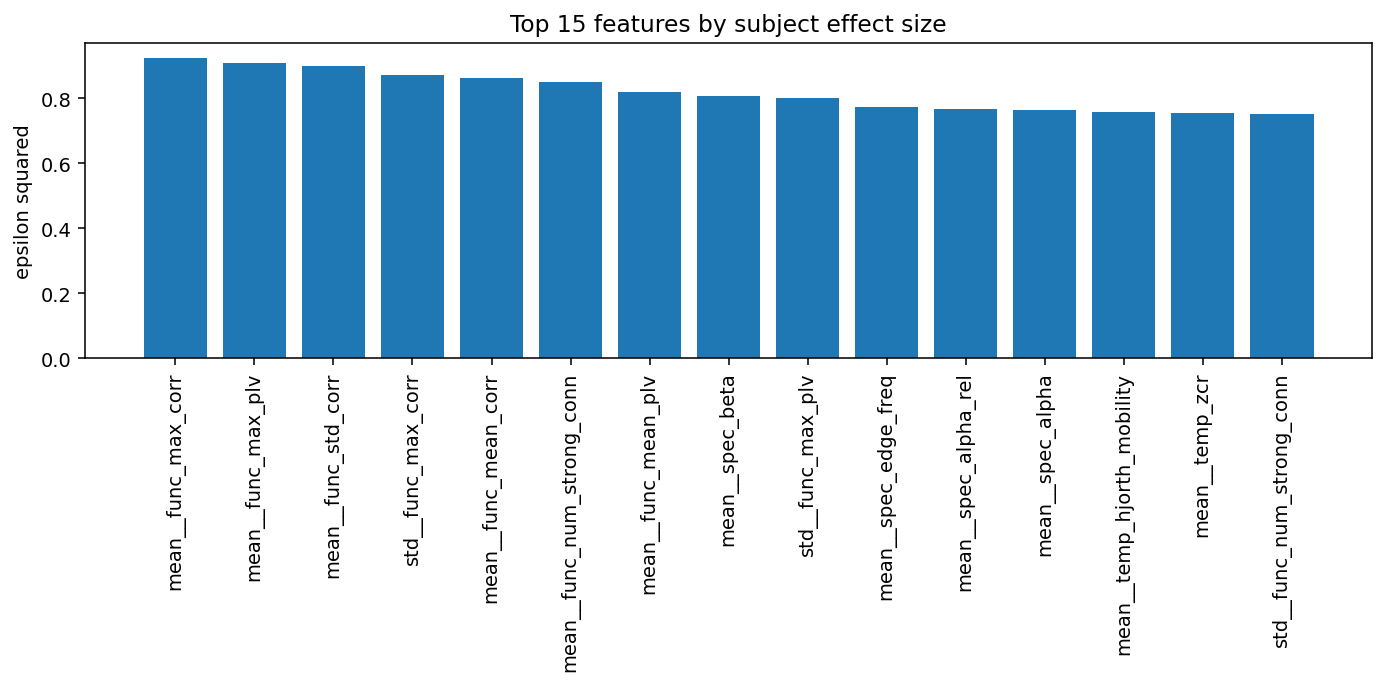

In [17]:
top15 = subject_results.sort_values("epsilon_sq", ascending=False).head(15).copy()

plt.figure(figsize=(10, 5), dpi=140)
plt.bar(range(len(top15)), top15["epsilon_sq"].values)
plt.xticks(range(len(top15)), top15["feature"].values, rotation=90)
plt.ylabel("epsilon squared")
plt.title("Top 15 features by subject effect size")
plt.tight_layout()
plt.show()


## Optional drill-down: one feature by word

Scegli una feature e guarda la distribuzione per alcune parole.


<Figure size 1680x700 with 0 Axes>

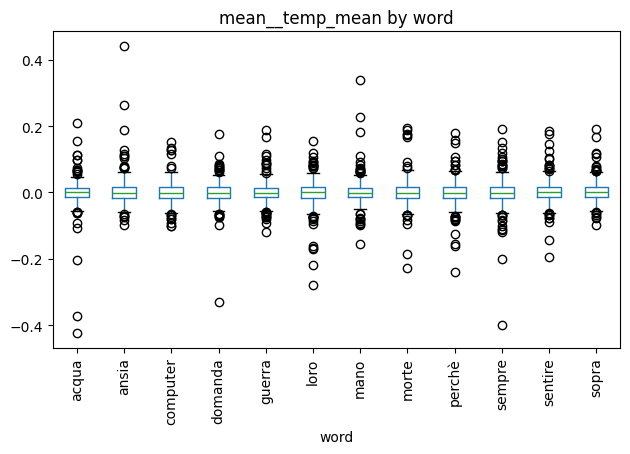

In [18]:
FEATURE_TO_PLOT = word_results.sort_values("epsilon_sq", ascending=False).iloc[0]["feature"]
TOP_N_WORDS = 12

if "word" in df.columns:
    top_words = df["word"].value_counts().index[:TOP_N_WORDS]
    tmp = df[df["word"].isin(top_words)]

    plt.figure(figsize=(12, 5), dpi=140)
    tmp.boxplot(column=FEATURE_TO_PLOT, by="word", rot=90, grid=False)
    plt.title(f"{FEATURE_TO_PLOT} by word")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'word' not available")


## Save results


In [19]:
out_dir = project_root / "data" / "processed" / "feature_significance"
out_dir.mkdir(parents=True, exist_ok=True)

word_results.to_csv(out_dir / "word_effect_kruskal.csv", index=False)
subject_results.to_csv(out_dir / "subject_effect_kruskal.csv", index=False)
session_results.to_csv(out_dir / "session_effect_kruskal.csv", index=False)
cmp.to_csv(out_dir / "word_vs_subject_effect_comparison.csv", index=False)

print("Saved results to:", out_dir)


Saved results to: /home/daniele_u/miralis-hypergraph-imagined-speech/data/processed/feature_significance


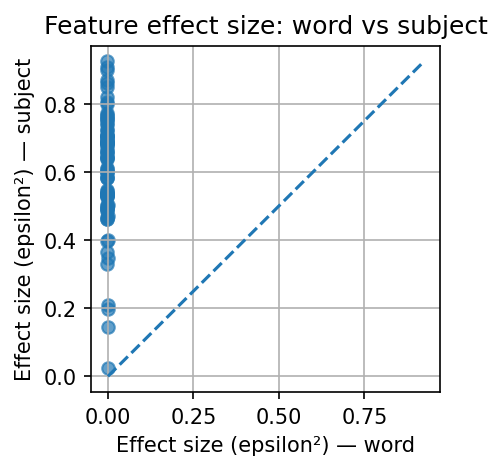

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)

cmp_path = project_root / "data/processed/feature_significance/word_vs_subject_effect_comparison.csv"

cmp = pd.read_csv(cmp_path)

plt.figure(figsize=(3,3), dpi=150)

plt.scatter(
    cmp["eps_word"],
    cmp["eps_subject"],
    alpha=0.7
)

mx = max(cmp["eps_subject"].max(), cmp["eps_word"].max())

plt.plot([0,mx],[0,mx],"--")

plt.xlabel("Effect size (epsilon²) — word")
plt.ylabel("Effect size (epsilon²) — subject")

plt.title("Feature effect size: word vs subject")

plt.grid(True)
plt.show()

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)

word = pd.read_csv(project_root / "data/processed/feature_significance/word_effect_kruskal.csv")
subject = pd.read_csv(project_root / "data/processed/feature_significance/subject_effect_kruskal.csv")
session = pd.read_csv(project_root / "data/processed/feature_significance/session_effect_kruskal.csv")

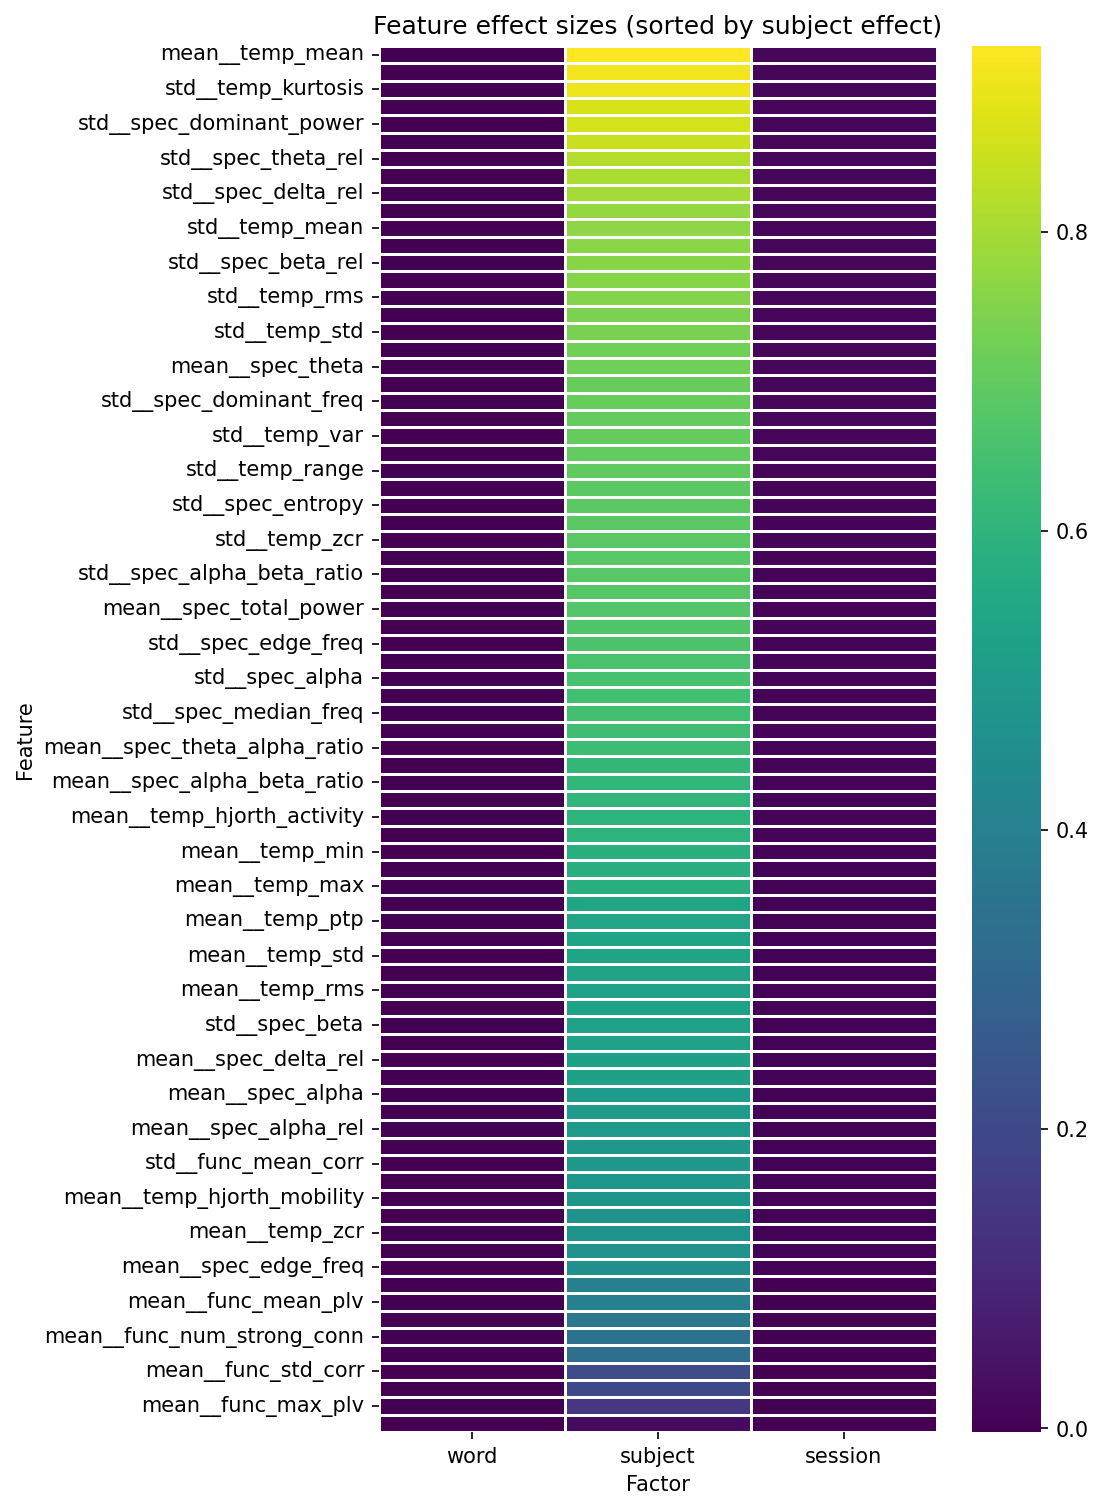

In [22]:
df = pd.DataFrame({
    "feature": word["feature"],
    "word": word["epsilon_sq"],
    "subject": subject["epsilon_sq"],
    "session": session["epsilon_sq"]
})

df = df.set_index("feature")
df_sorted = df.sort_values("subject", ascending=False)

plt.figure(figsize=(6,12), dpi=150)

sns.heatmap(
    df_sorted,
    cmap="viridis",
    linewidths=0.5
)

plt.title("Feature effect sizes (sorted by subject effect)")
plt.xlabel("Factor")
plt.ylabel("Feature")

plt.show()
plt.show()